In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Analysis of Zohran Mamdani's 2025 Mayoral Win

In [ ]:
# import data source
df = gpd.read_file('VoteHub Tech/VH_skills.geojson')
df = df[(df['v_20_c_T'] > 0) & (df['P_D_Est'] > 0) & (df['P_R_Est'] > 0)]

## Basic Performance Picture

In [ ]:
""" county_results groups by county and aggregates based on total votes for each
    candidate. It also calculates the share of votes for each candidate. """

county_results = df.groupby('County').agg(
    mamdani_vote_total = ('Zohran Kwame Mamdani', 'sum'),
    cuomo_vote_total = ('Andrew M. Cuomo', 'sum'),
    sliwa_vote_total = ('Curtis A. Sliwa', 'sum'),
    total_votes = ('Total', 'sum'),
    ).assign(
    mamdani_share=lambda x: x['mamdani_vote_total'] / x['total_votes'],
    cuomo_share=lambda x: x['cuomo_vote_total'] / x['total_votes'],
    sliwa_share=lambda x: x['sliwa_vote_total'] / x['total_votes'])

""" county_res_byAD groups by county and assembly district and aggregates based on
    total votes for each candidate. It also calculates the share of votes for each
    candidate. """

county_res_byAD = df.groupby(['ad', 'ed']).agg(
    mamdani_vote_total = ('Zohran Kwame Mamdani', 'sum'),
    cuomo_vote_total = ('Andrew M. Cuomo', 'sum'),
    sliwa_vote_total = ('Curtis A. Sliwa', 'sum'),
    total_votes = ('Total', 'sum'),
    ).assign(
    mamdani_share=lambda x: x['mamdani_vote_total'] / x['total_votes'],
    cuomo_share=lambda x: x['cuomo_vote_total'] / x['total_votes'],
    sliwa_share=lambda x: x['sliwa_vote_total'] / x['total_votes'])

display(county_results)

,mamdani_vote_total,cuomo_vote_total,sliwa_vote_total,total_votes,mamdani_share,cuomo_share,sliwa_share
County,,,,,,,
Bronx,113633.0,88962.0,15612.0,220640.0,0.515015,0.403200,0.070758
Kings,369184.0,243953.0,32135.0,651433.0,0.566726,0.374487,0.049330
New York,273650.0,223815.0,17481.0,519981.0,0.526269,0.430429,0.033619
Queens,236016.0,210632.0,48449.0,499140.0,0.472845,0.421990,0.097065
Richmond,32678.0,79693.0,30518.0,143760.0,0.227309,0.554348,0.212284


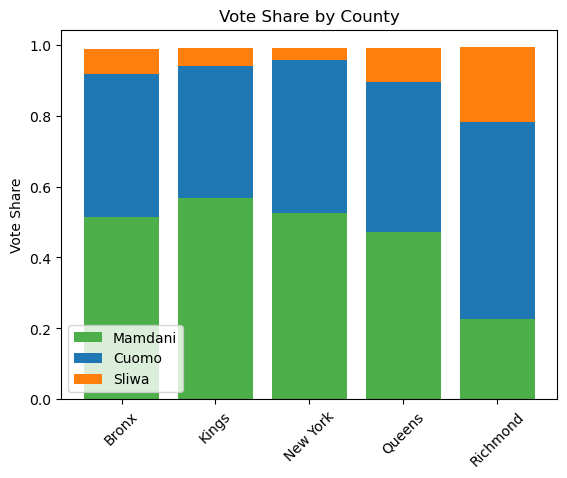

In [ ]:
shares = county_results[["mamdani_share", "cuomo_share", "sliwa_share"]]
plt.bar(shares.index, shares["mamdani_share"], color="#4daf4a", label="Mamdani")
plt.bar(shares.index, shares["cuomo_share"], bottom=shares["mamdani_share"], label="Cuomo")
plt.bar(shares.index, shares["sliwa_share"], bottom=shares["mamdani_share"] + shares["cuomo_share"], label="Sliwa")

plt.ylabel("Vote Share")
plt.title("Vote Share by County")
plt.xticks(rotation=45)
plt.legend()

plt.show()

## Where Did Mamdani Overperform or Underperform?

In [ ]:
vote_share_2024 = df.groupby(['ed', 'ad']).agg(
    harris_vote_total = ('P_D_Est', 'sum'),
    trump_vote_total = ('P_R_Est', 'sum'),
    vote_total = ('P_Tt_Es', 'sum')
    ).assign(
        dem_share=lambda x: x['harris_vote_total'] / x['vote_total'],
        repub_share=lambda x: x['trump_vote_total'] / x['vote_total'])

results_ED = df.groupby(['ed', 'ad']).agg(
    mamdani_vote_total = ('Zohran Kwame Mamdani', 'sum'),
    cuomo_vote_total = ('Andrew M. Cuomo', 'sum'),
    sliwa_vote_total = ('Curtis A. Sliwa', 'sum'),
    total_votes = ('Total', 'sum'),
    ).assign(
    mamdani_share=lambda x: x['mamdani_vote_total'] / x['total_votes'],
    cuomo_share=lambda x: x['cuomo_vote_total'] / x['total_votes'],
    sliwa_share=lambda x: x['sliwa_vote_total'] / x['total_votes']).reset_index()

results_ED = results_ED.merge(vote_share_2024, on=['ad','ed'], how='inner')
ED_clean = results_ED[results_ED['vote_total'] > 0]

Intercept: 0.023280197674882763
Slope: 0.7248138316576358
R^2: 0.6117828712629988


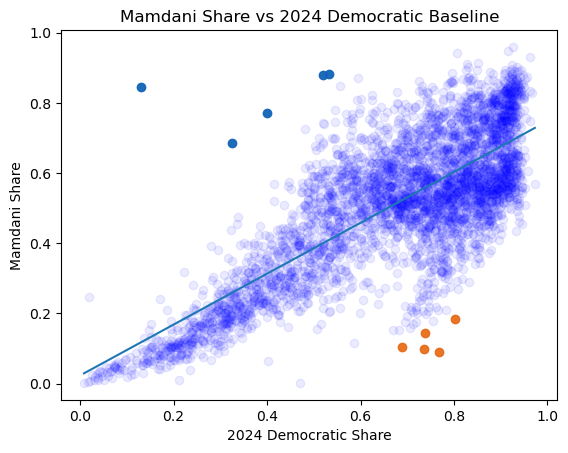

In [ ]:
X = ED_clean[['dem_share']].values
y = ED_clean['mamdani_share'].values

model = LinearRegression()
model.fit(X, y)

# Intercept (baseline Mamdani share when dem_share = 0)
print("Intercept:", model.intercept_)
# Slope (how much Mamdani share rises per 1% increase in Democratic share)
print("Slope:", model.coef_[0])
# R**2 (strength of partisan alignment)
print("R^2:", model.score(X, y))


# calculating residuals
ED_clean['predicted'] = model.predict(X)
ED_clean['residual'] = ED_clean['mamdani_share'] - ED_clean['predicted']

# largest overperforming districts
over = ED_clean.sort_values('residual', ascending=False).head(5)

# largest underperforming districts
under = ED_clean.sort_values('residual', ascending=True).head(5)

plt.scatter(over['dem_share'], over['mamdani_share'])
plt.scatter(under['dem_share'], under['mamdani_share'])
plt.scatter(ED_clean['dem_share'], ED_clean['mamdani_share'], alpha=0.08, color='blue')

x_range = np.linspace(ED_clean['dem_share'].min(), ED_clean['dem_share'].max(), 200).reshape(-1, 1)
y_pred_line = model.predict(x_range)

plt.plot(x_range, y_pred_line)

plt.xlabel("2024 Democratic Share")
plt.ylabel("Mamdani Share")
plt.title("Mamdani Share vs 2024 Democratic Baseline")
plt.show()

In [ ]:
keep = ['ad', 'ed', 'mamdani_share', 'dem_share', 'predicted', 'residual']
over_clean = over[keep]
under_clean = under[keep]

# top overperforming districts
display(over_clean)

,ad,ed,mamdani_share,dem_share,predicted,residual
2701,AD 42,ED 48,0.844828,0.130435,0.117821,0.727006
2432,AD 24,ED 44,0.878481,0.519231,0.399626,0.478855
730,AD 54,ED 2,0.880753,0.532934,0.409558,0.471195
3780,AD 44,ED 75,0.770171,0.400000,0.313206,0.456965
84,AD 47,ED 10,0.684807,0.325956,0.259537,0.425270


In [ ]:
# top underperforming districts
display(under_clean.head(5))

,ad,ed,mamdani_share,dem_share,predicted,residual
64,AD 26,ED 10,0.090909,0.767233,0.579381,-0.488472
128,AD 26,ED 11,0.097561,0.735780,0.556584,-0.459023
1585,AD 73,ED 31,0.184066,0.802211,0.604734,-0.420668
752,AD 76,ED 2,0.104000,0.689362,0.522939,-0.418939
3272,AD 73,ED 57,0.142857,0.738329,0.558431,-0.415574


For (AD 26, ED 10) and (AD 26, ED 11), it was surprising to see Mamdani's vote share so far below the Democratic baseline for the 2024 election. Furthermore, Assembly District 26 is in Queens, where Cuomo saw a lot of support. This is probably the reason for Mamdani's underperformance compared to the Democratic baseline, it's most likely that more conservative Democrats are located in this district. Furthermore, Assembly District 73 is near Midtown Manhattan, which also saw heavy swings towards Cuomo.

## What Might Explain the Outliers?

In [ ]:
df.drop(columns=[
    'X_22_2022_Age_Expanded_Age_0_5',
    'X_22_2022_Age_Expanded_Age_5_9',
    'X_22_2022_Age_Expanded_Age_10_14'
], inplace=True, errors='ignore')

age_cols = [c for c in df.columns if c.startswith("X_22_2022_Age_Expanded")]
df["total_age_count"] = df[age_cols].sum(axis=1)
df["under35_count"] = (
      df["X_22_2022_Age_Expanded_Age_15_19"]
    + df["X_22_2022_Age_Expanded_Age_20_24"]
    + df["X_22_2022_Age_Expanded_Age_25_29"]
    + df["X_22_2022_Age_Expanded_Age_30_34"]
)

df["under35_share"] = df["under35_count"] / df["total_age_count"]
df["mamdani_share"] = df["Zohran Kwame Mamdani"] / df["Total"]

demo = (df.groupby(['ad', 'ed'])
         .agg({
             'v_20_c_W' : 'sum',
             'v_20_c_B' : 'sum',
             'v_20_c_A' : 'sum',
             'v_20_c_H' : 'sum',
             'v_20_c_T' : 'sum',
         })
       ).assign(
    white_share = demo['v_20_c_W'] / demo['v_20_c_T'],
    black_share = demo['v_20_c_B'] / demo['v_20_c_T'],
    asian_share = demo['v_20_c_A'] / demo['v_20_c_T'],
    hisp_share  = demo['v_20_c_H'] / demo['v_20_c_T'])

merged = df.merge(
    ED_clean,
    on=['ad', 'ed'],
    how='left'
)

merged_demo = df.merge(
    demo,
    on=['ad', 'ed'],
    how='right'
)

over = merged.sort_values("residual", ascending=False).head(5)
under = merged.sort_values("residual", ascending=True).head(5)

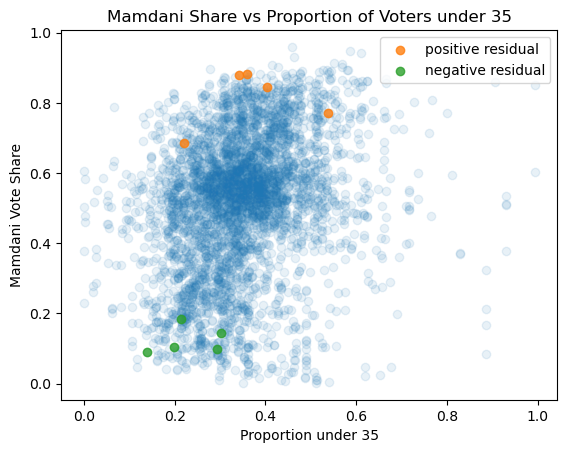

In [ ]:
plt.scatter(merged['under35_share'],
    merged['mamdani_share_x'],
    alpha=0.1
)

plt.scatter(over['under35_share'], over['mamdani_share_x'], alpha=0.8, label='positive residual')

plt.scatter(under['under35_share'], under['mamdani_share_x'], alpha=0.8, label='negative residual')

plt.xlabel("Proportion under 35")
plt.ylabel("Mamdani Vote Share")
plt.title("Mamdani Share vs Proportion of Voters under 35")
plt.legend()
plt.show()

As the proportion of voters under 35 grows, Mamdani's vote share grows, which indicates a positive relationship. Mamdani did better in younger districts. In terms of our residuals, we can see that the districts where we overestimated had a higher proportion of voters under 35.

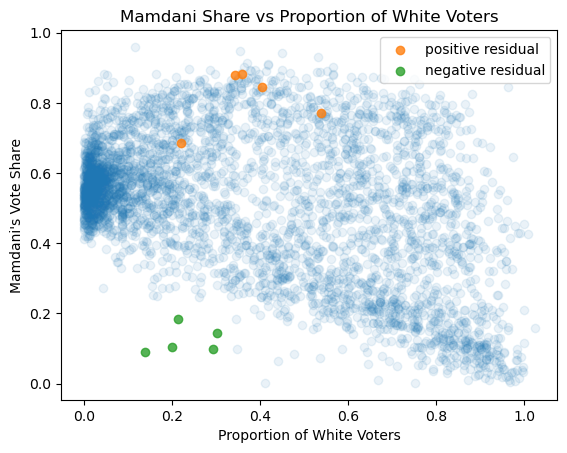

In [ ]:
plt.scatter(merged_demo['white_share'],
    merged_demo['mamdani_share'],
    alpha=0.09
)

plt.scatter(over['under35_share'], over['mamdani_share_x'], alpha=0.8, label='positive residual')
plt.scatter(under['under35_share'], under['mamdani_share_x'], alpha=0.8, label='negative residual')

plt.xlabel("Proportion of White Voters")
plt.ylabel("Mamdani's Vote Share")
plt.title("Mamdani Share vs Proportion of White Voters")
plt.legend()
plt.show()

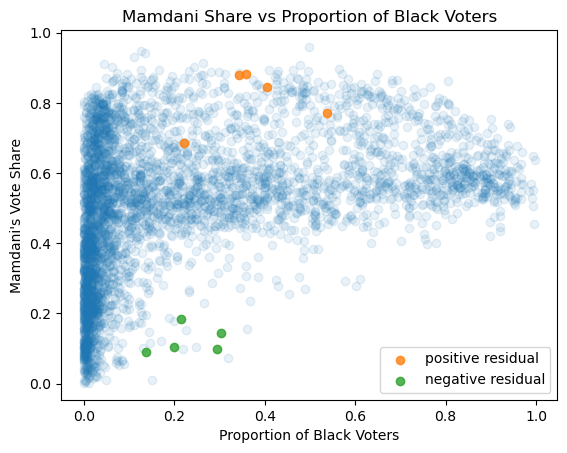

In [ ]:
plt.scatter(merged_demo['black_share'],
    merged_demo['mamdani_share'],
    alpha=0.1
)

plt.scatter(over['under35_share'], over['mamdani_share_x'], alpha=0.8, label='positive residual')

plt.scatter(under['under35_share'], under['mamdani_share_x'], alpha=0.8, label='negative residual')

plt.xlabel("Proportion of Black Voters")
plt.ylabel("Mamdani's Vote Share")
plt.title("Mamdani Share vs Proportion of Black Voters")
plt.legend()
plt.show()

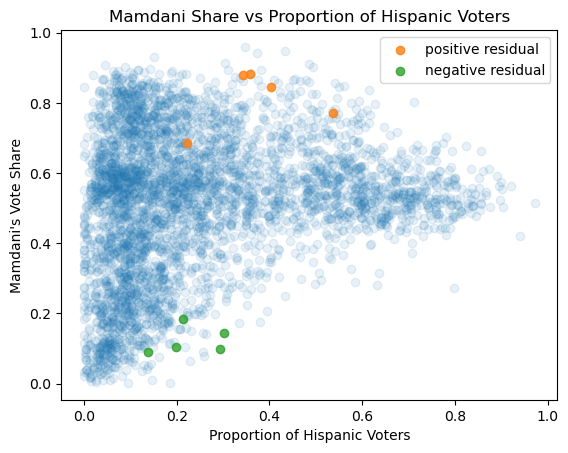

In [ ]:
plt.scatter(merged_demo['hisp_share'],
    merged_demo['mamdani_share'],
    alpha=0.1
)

plt.scatter(over['under35_share'], over['mamdani_share_x'], alpha=0.8, label='positive residual')
plt.scatter(under['under35_share'], under['mamdani_share_x'], alpha=0.8, label='negative residual')

plt.xlabel("Proportion of Hispanic Voters")
plt.ylabel("Mamdani's Vote Share")
plt.title("Mamdani Share vs Proportion of Hispanic Voters")
plt.legend()
plt.show()

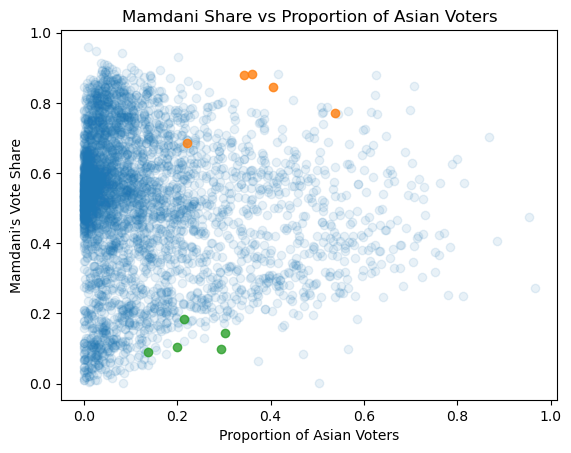

In [ ]:
plt.scatter(merged_demo['asian_share'],
    merged_demo['mamdani_share'],
    alpha=0.1
)
plt.scatter(over['under35_share'], over['mamdani_share_x'], alpha=0.8, label='positive residual')
plt.scatter(under['under35_share'], under['mamdani_share_x'], alpha=0.8, label='negative residual')

plt.xlabel("Proportion of Asian Voters")
plt.ylabel("Mamdani's Vote Share")
plt.title("Mamdani Share vs Proportion of Asian Voters")
plt.show()

In terms of racial demographics, Mamdani's vote share as we increase the proportion of white voters shows a clear negative relationship. For Asians, it seems to show a weak, yet positive relationship. For Black and Hispanic voters, there is little evidence of a linear relationship.

In terms of what is missing from the data, the first thing I notice is the grouping of Asian ethnicities. Korean vs. Japanese vs. Pakistani mark huge cultural differences and voting preferences, Mamdani himself is South Asian and draws a large base of support from that community, so the grouping of all Asians into one demographic column could mean we are underestimating the support of the South Asian community. Secondly, religion is also something that is missing, yet remains an important influence in American politics. A central theme of the campaign was Mamdani's religion as a Muslim man and his strong opposition to the Israeli government. Religious communities cluster together, which may help to explain under/overperformance for certain districts.

## Predictive Model

In [ ]:
final_df = pd.merge(merged_demo, ED_clean, on=['ad', 'ed'], how='left')

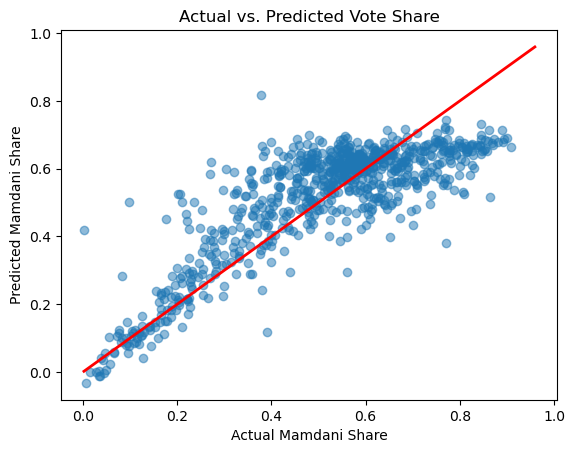

In [ ]:
features = [
    'dem_share',
    'under35_share',
    'asian_share',
    'black_share',
    'hisp_share',
    'white_share'
]
target = 'mamdani_share_y'

model_df = final_df[features + [target]].dropna()
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r-', lw=2)
plt.xlabel("Actual Mamdani Share")
plt.ylabel("Predicted Mamdani Share")
plt.title("Actual vs. Predicted Vote Share")
plt.show()

In [ ]:
print(f"Model Performance:")
print(f"RMSE: {rmse:.4f} (Average error in vote share points)")
print(f"R²: {r2:.4f} (Proportion of variance explained)")

coefficients = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
print(coefficients.sort_values(by='Coefficient', ascending=False))

Model Performance:
RMSE: 0.1143 (Average error in vote share points)
R²: 0.6733 (Proportion of variance explained)
         Feature  Coefficient
0      dem_share     0.748998
1  under35_share     0.226831
2    asian_share    -0.025861
4     hisp_share    -0.113653
3    black_share    -0.270584
5    white_share    -0.283873


For my simple, predictive model, I conducted OLS regression and modeled Mamdani's vote share in a precinct as a linear function of the baseline Democratic performance in 2024, the proportion of young voters (under 35), racial demographics, and an error term with an expected value of 0.

$$
\text{VoteShare}_{mamdani} = \beta_0 + \beta_1(\text{DemShare}) + \beta_2(\text{Under35}) + \beta_3(\text{Asian}) + \beta_4(\text{Black}) + \beta_5(\text{Hispanic}) + \beta_6(\text{White}) + u_i
$$